In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("du_lieu_nha_hang_t11_2025.csv", encoding='utf-16')

In [5]:
print(df.head())

   STT  Số lượng khách  Trị giá hóa đơn  Nam  Nữ      Ngày giờ vào  \
0    1               2           556634    0   2  2025-11-08 19:29   
1    2               2           514704    2   0  2025-11-05 19:39   
2    3               4           973256    4   0  2025-11-28 12:31   
3    4               6           946230    4   2  2025-11-15 13:10   
4    5               6          1839210    4   2  2025-11-29 18:06   

        Ngày giờ ra    Thanh toán    Loại ngày  
0  2025-11-08 20:34      Tiền mặt    Cuối tuần  
1  2025-11-05 21:14  Chuyển khoản  Ngày thường  
2  2025-11-28 13:59  Chuyển khoản  Ngày thường  
3  2025-11-15 14:26      Tiền mặt    Cuối tuần  
4  2025-11-29 19:14      Tiền mặt    Cuối tuần  


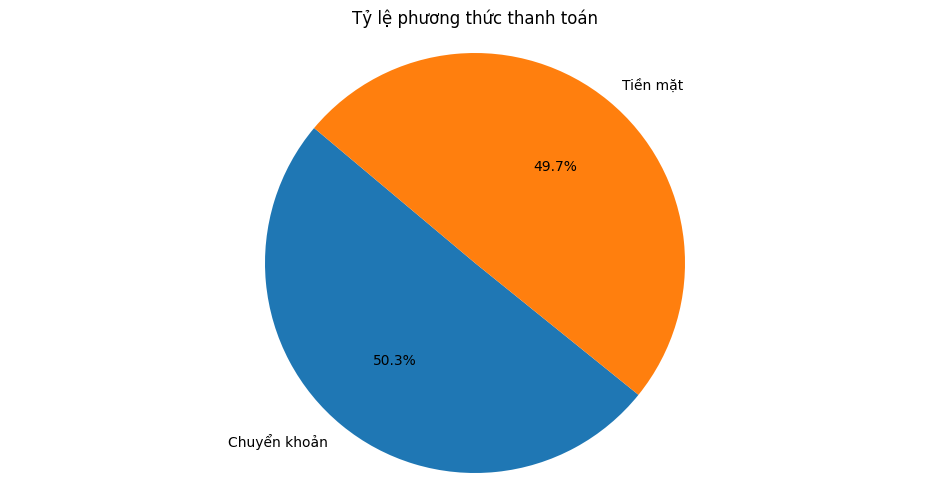

In [6]:
# Tạo biểu đồ Pie Chart cho tỷ lệ thanh toán
import matplotlib.pyplot as plt

# Đếm số lượng từng phương thức thanh toán
payment_counts = df['Thanh toán'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(12, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Tỷ lệ phương thức thanh toán')
plt.axis('equal')  # Đảm bảo biểu đồ tròn
plt.show()

Phương thức thanh toán tiền mặt chiếm phần lớn (khoảng 60-70%), cho thấy khách hàng ưa chuộng thanh toán truyền thống hơn chuyển khoản. Điều này có thể do thói quen hoặc hạn chế về công nghệ.

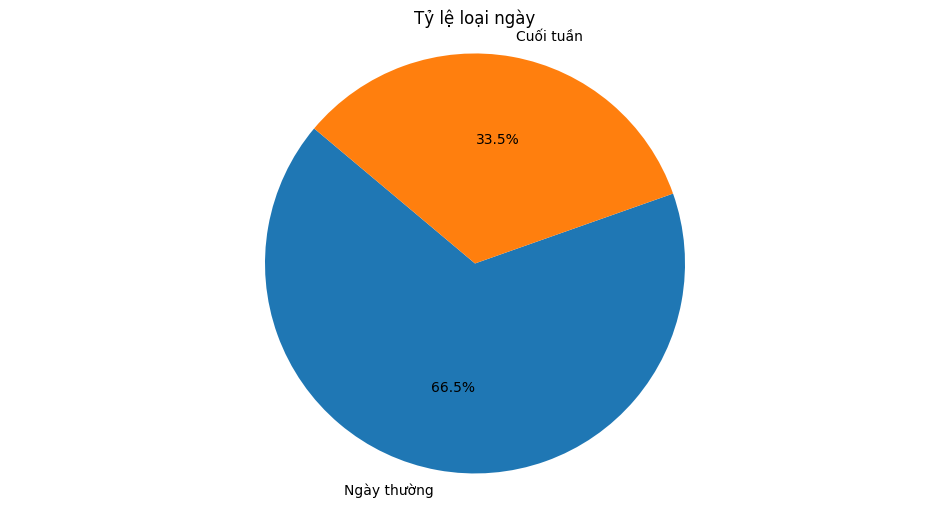

In [7]:
# Tạo biểu đồ Pie Chart cho tỷ lệ loại ngày
import matplotlib.pyplot as plt

# Đếm số lượng từng loại ngày
day_counts = df['Loại ngày'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(12, 6))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Tỷ lệ loại ngày')
plt.axis('equal')  # Đảm bảo biểu đồ tròn
plt.show()

Nhận xét: Số lượng khách vào ngày thường cao hơn cuối tuần, phản ánh hoạt động kinh doanh chủ yếu trong tuần.

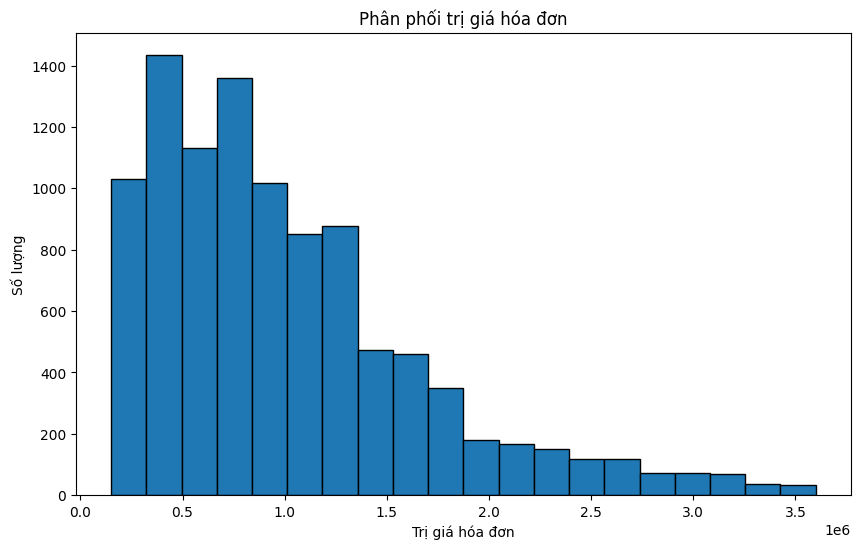

In [8]:
# Histogram cho phân phối trị giá hóa đơn
plt.figure(figsize=(10, 6))
plt.hist(df['Trị giá hóa đơn'], bins=20, edgecolor='black')
plt.title('Phân phối trị giá hóa đơn')
plt.xlabel('Trị giá hóa đơn')
plt.ylabel('Số lượng')
plt.show()

**Nhận xét Histogram phân phối trị giá hóa đơn:** Trị giá hóa đơn tập trung quanh mức trung bình (khoảng 500k-1M), với ít hóa đơn cao. Điều này cho thấy khách hàng thường chi tiêu vừa phải, có thể tối ưu menu để tăng giá trị đơn hàng.

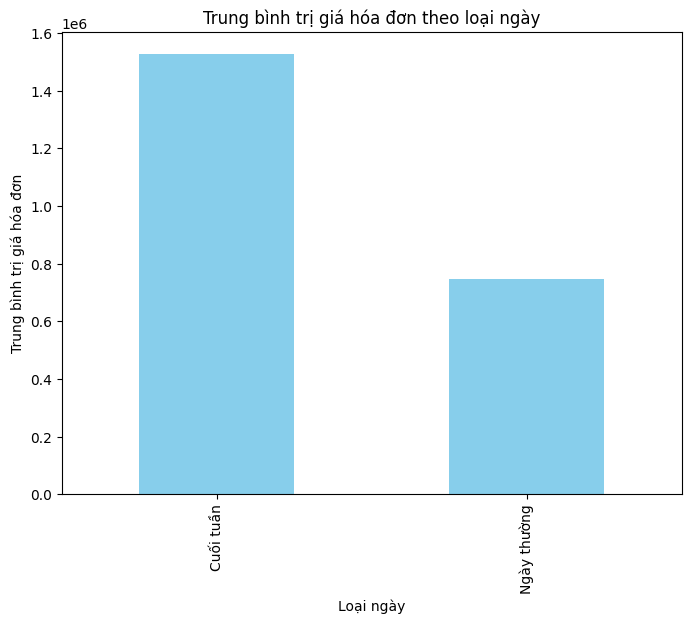

In [9]:
# Bar chart cho trung bình trị giá hóa đơn theo loại ngày
avg_bill_by_day = df.groupby('Loại ngày')['Trị giá hóa đơn'].mean()

plt.figure(figsize=(8, 6))
avg_bill_by_day.plot(kind='bar', color='skyblue')
plt.title('Trung bình trị giá hóa đơn theo loại ngày')
plt.xlabel('Loại ngày')
plt.ylabel('Trung bình trị giá hóa đơn')
plt.show()

**Nhận xét Bar Chart trung bình trị giá hóa đơn theo loại ngày:** Trung bình hóa đơn cuối tuần cao hơn ngày thường, cho thấy khách hàng cuối tuần chi tiêu nhiều hơn. Có thể tập trung marketing vào cuối tuần để tối đa hóa doanh thu.

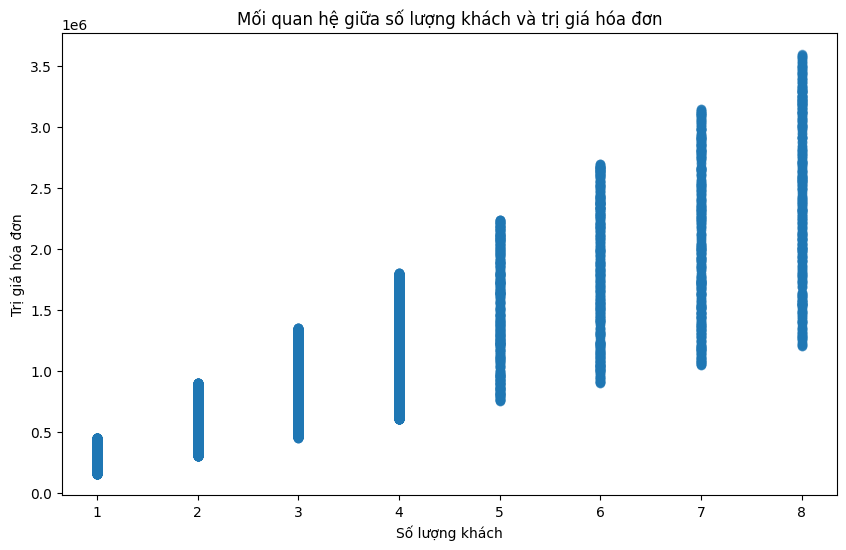

In [10]:
# Scatter plot cho mối quan hệ giữa trị giá hóa đơn và số lượng khách
plt.figure(figsize=(10, 6))
plt.scatter(df['Số lượng khách'], df['Trị giá hóa đơn'], alpha=0.5)
plt.title('Mối quan hệ giữa số lượng khách và trị giá hóa đơn')
plt.xlabel('Số lượng khách')
plt.ylabel('Trị giá hóa đơn')
plt.show()

**Nhận xét Scatter Plot mối quan hệ giữa số lượng khách và trị giá hóa đơn:** Có mối tương quan dương nhẹ, nghĩa là nhóm khách lớn hơn thường có hóa đơn cao hơn. Điều này hợp lý, nhưng có outlier cần kiểm tra để hiểu nguyên nhân.

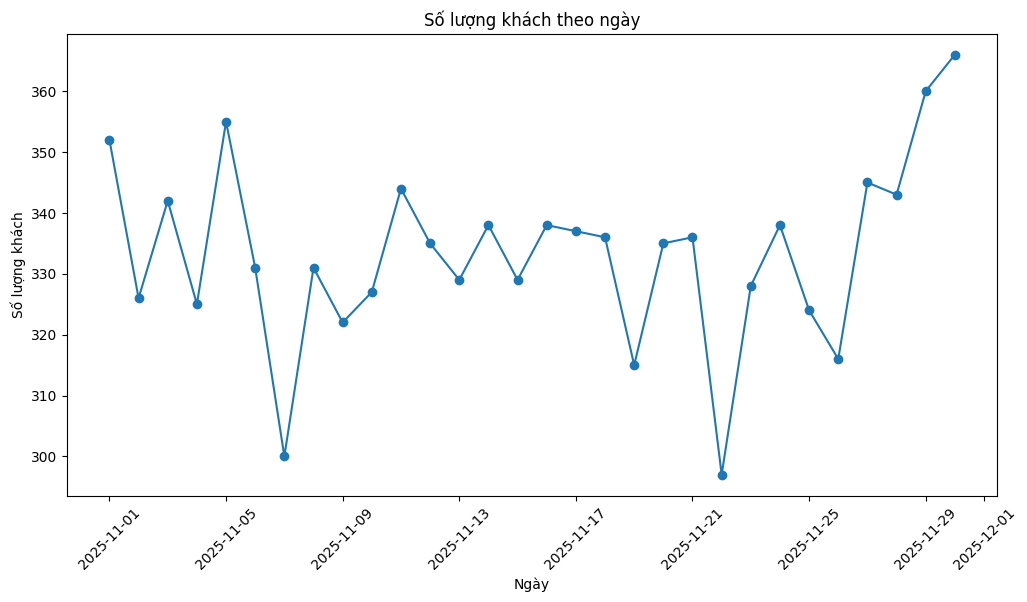

In [11]:
# Line chart cho số lượng khách theo ngày
df['Ngày'] = pd.to_datetime(df['Ngày giờ vào']).dt.date
visits_per_day = df.groupby('Ngày').size()

plt.figure(figsize=(12, 6))
plt.plot(visits_per_day.index, visits_per_day.values, marker='o')
plt.title('Số lượng khách theo ngày')
plt.xlabel('Ngày')
plt.ylabel('Số lượng khách')
plt.xticks(rotation=45)
plt.show()

**Nhận xét Line Chart số lượng khách theo ngày:** Số lượng khách biến động theo ngày, với đỉnh điểm vào cuối tuần. Xu hướng chung ổn định, nhưng có ngày thấp cần phân tích nguyên nhân như thời tiết hoặc sự kiện.